In [ ]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")
# Dataset
df = pd.read_csv(r"C:\Users\ASUS\Documents\Personal Things\Project\Bank's Customer Churn Analysis & Prediction\bankchurn.csv", 
                 encoding='utf-8-sig') 
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
# Rename target variable: exit → Exited and convert to binary
df['Exited'] = df['exit'].map({True: 1, False: 0, 'TRUE': 1, 'FALSE': 0})
df = df.drop(columns=['exit'])

Dataset shape: (80000, 26)

Column names:
['id', 'full_name', 'credit_sco', 'gender', 'age', 'occupation', 'balance', 'monthly_ir', 'address', 'origin_province', 'tenure_ye', 'married', 'nums_card', 'nums_service', 'active_member', 'last_active_date', 'last_transaction_month', 'created_date', 'exit', 'customer_segment', 'engagement_score', 'loyalty_level', 'digital_behavior', 'risk_score', 'risk_segment', 'cluster_group']


In [ ]:
print("\nFirst 5 rows of the dataset:")
print(df.head())
print("\nDataset Info:")
df.info()
df.describe()


First 5 rows of the dataset:
   id         full_name  credit_sco  gender  age            occupation  \
0   1       Đặng Văn Vũ         725    male   55  Chủ Doanh nghiệp nhỏ   
1   2      Bùi Hữu Phúc         689    male   45     Nội trợ/Sinh viên   
2   3        Lê Văn Mai         702  female   44  Chủ Doanh nghiệp nhỏ   
3   4  Dương Trần Nhiên         766    male   44  Chủ Doanh nghiệp nhỏ   
4   5    Dương Thu Linh         677  female   77  Giáo viên/Giảng viên   

     balance  monthly_ir                 address  origin_province  tenure_ye  \
0  177306004   121000000      Phường An Hội (BT)  TP. Hồ Chí Minh          0   
1    1927416     5000000   Phường Bến Thành (Q1)         Đồng Nai          3   
2  304931745   109000000   Phường Hòa Bình (Q11)  TP. Hồ Chí Minh          4   
3   50615501    79000000           Phường 7 (Q7)  TP. Hồ Chí Minh          3   
4   40532432    25000000  Phường Thắng Lợi (Q10)  TP. Hồ Chí Minh          2   

   married  nums_card  nums_service  active_

,id,credit_sco,age,balance,monthly_ir,tenure_ye,married,nums_card,nums_service,last_transaction_month,engagement_score,risk_score,cluster_group,Exited
count,80000.000000,80000.000000,80000.000000,8.000000e+04,8.000000e+04,80000.000000,80000.000000,80000.000000,80000.000000,8.000000e+04,80000.000000,80000.000000,80000.000000,80000.00000
mean,40000.500000,684.321137,49.381862,6.118320e+07,3.778820e+07,1.777250,0.970825,2.634688,3.564425,8.831755e+06,31.725400,0.269260,1.971037,0.18000
std,23094.155105,51.169733,15.067480,8.868620e+07,3.655107e+07,1.315828,0.694698,1.218556,2.002448,3.378683e+07,23.474862,0.091891,1.040763,0.38419
min,1.000000,495.000000,20.000000,4.086630e+05,3.000000e+06,0.000000,0.000000,1.000000,1.000000,0.000000e+00,7.000000,0.017300,1.000000,0.00000
25%,20000.750000,649.000000,38.000000,1.462592e+07,1.400000e+07,1.000000,1.000000,2.000000,2.000000,0.000000e+00,16.000000,0.200400,1.000000,0.00000
50%,40000.500000,682.000000,47.000000,3.090276e+07,2.300000e+07,2.000000,1.000000,2.000000,3.000000,0.000000e+00,22.000000,0.277400,2.000000,0.00000
75%,60000.250000,718.000000,58.000000,6.960994e+07,4.700000e+07,3.000000,1.000000,3.000000,5.000000,0.000000e+00,38.000000,0.338900,2.000000,0.00000
max,80000.000000,800.000000,90.000000,1.000000e+09,2.160000e+08,4.000000,3.000000,5.000000,8.000000,6.000000e+08,100.000000,0.540400,4.000000,1.00000


In [ ]:
# Kiểm tra dữ liệu thiếu
print("\nMissing values:")
print(df.isnull().sum())
print("\nChurn distribution:")
print(df['Exited'].value_counts(normalize=True))
print(f"\nChurn rate: {df['Exited'].mean():.2%}")
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)


Missing values:
id                        0
full_name                 0
credit_sco                0
gender                    0
age                       0
occupation                0
balance                   0
monthly_ir                0
address                   0
origin_province           0
tenure_ye                 0
married                   0
nums_card                 0
nums_service              0
active_member             0
last_active_date          0
last_transaction_month    0
created_date              0
customer_segment          0
engagement_score          0
loyalty_level             0
digital_behavior          0
risk_score                0
risk_segment              0
cluster_group             0
Exited                    0
dtype: int64

Churn distribution:
Exited
0    0.82
1    0.18
Name: proportion, dtype: float64

Churn rate: 18.00%

Duplicate rows: 0

Data types:
id                          int64
full_name                  object
credit_sco                  int64
gender 

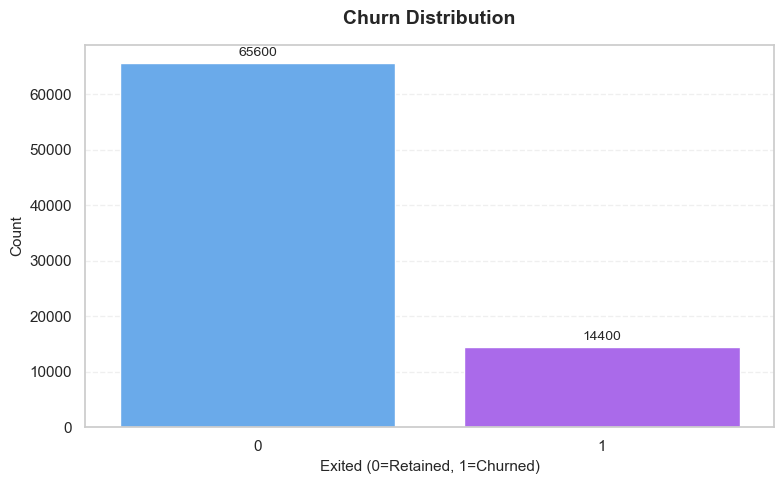

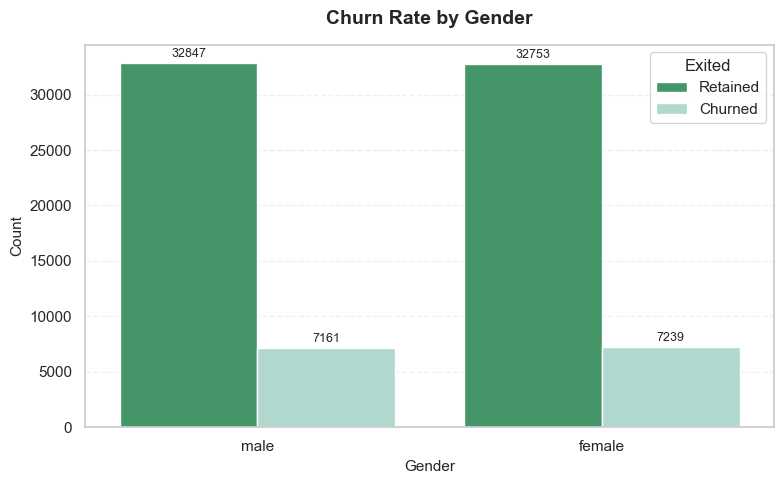

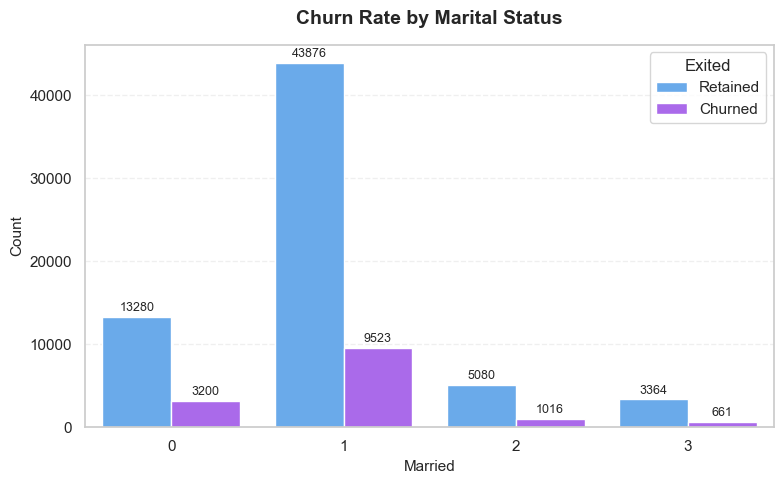

<ipython-input-4-20960ed799af>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='age', data=df, palette='BuGn_r', linewidth=2, width=0.5)


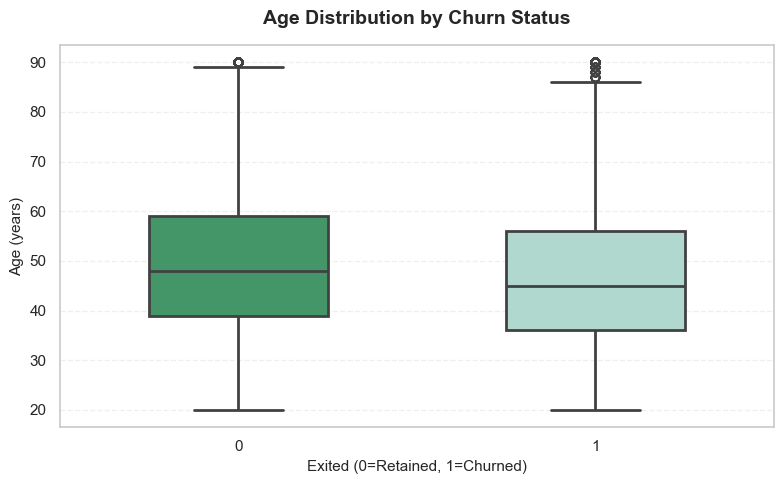

<ipython-input-4-20960ed799af>:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='balance', data=df, palette='cool', linewidth=2, width=0.5)


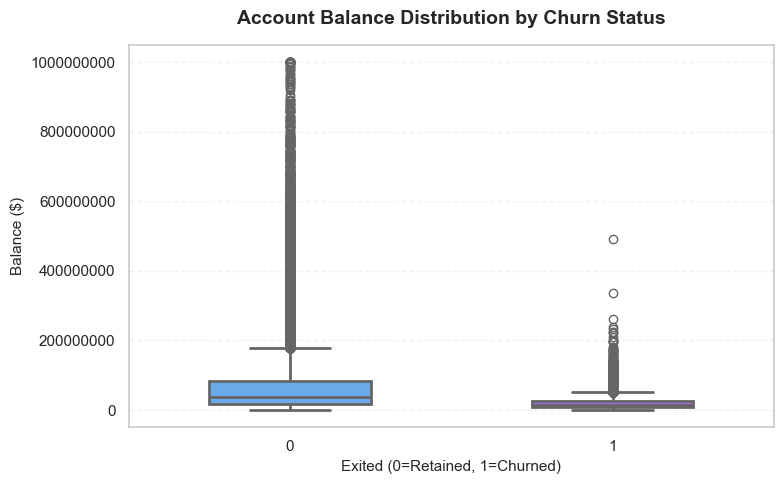

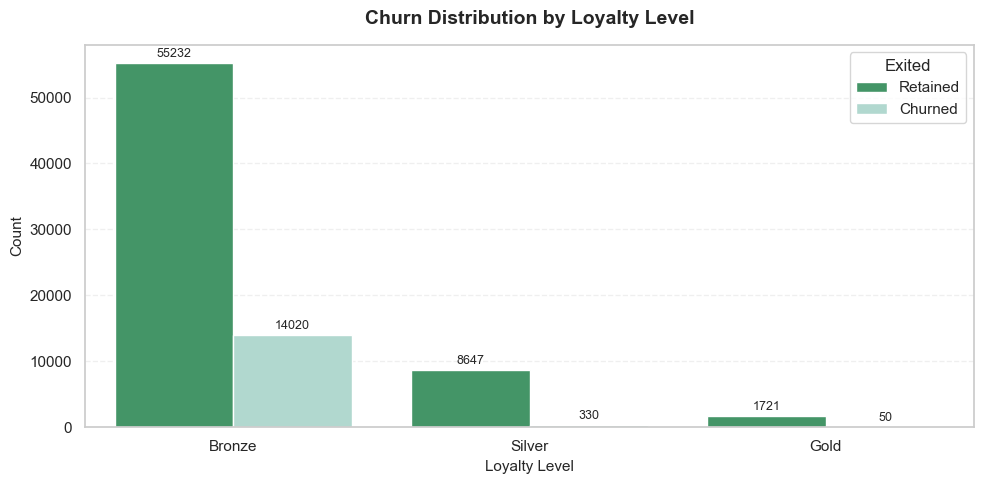

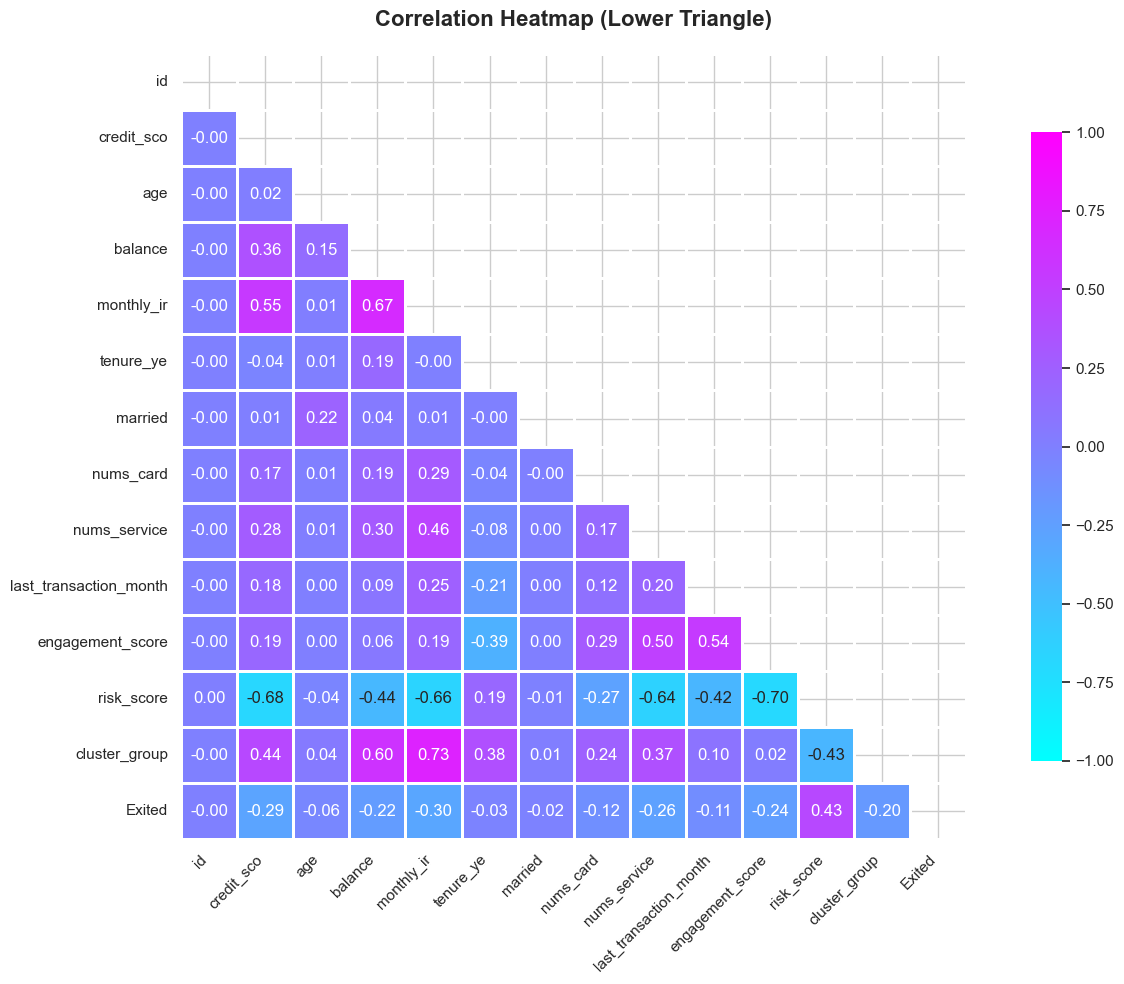

In [ ]:
# Churn rate
plt.figure(figsize=(8,5))
ax = sns.countplot(x='Exited', data=df, hue='Exited', palette='cool', legend=False)
plt.title("Churn Distribution", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Exited (0=Retained, 1=Churned)", fontsize=11)
plt.ylabel("Count", fontsize=11)
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Churn theo giới tính (gender)
if 'gender' in df.columns:
    plt.figure(figsize=(8,5))
    ax = sns.countplot(x='gender', hue='Exited', data=df, palette='BuGn_r')
    plt.title("Churn Rate by Gender", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Gender", fontsize=11)
    plt.ylabel("Count", fontsize=11)
    plt.legend(title='Exited', labels=['Retained', 'Churned'], loc='upper right')
    for container in ax.containers:
        ax.bar_label(container, fontsize=9, padding=2)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

# Churn theo tình trạng hôn nhân (married)
if 'married' in df.columns:
    plt.figure(figsize=(8,5))
    ax = sns.countplot(x='married', hue='Exited', data=df, palette='cool')
    plt.title("Churn Rate by Marital Status", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Married", fontsize=11)
    plt.ylabel("Count", fontsize=11)
    plt.legend(title='Exited', labels=['Retained', 'Churned'], loc='upper right')
    for container in ax.containers:
        ax.bar_label(container, fontsize=9, padding=2)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

# Churn theo độ tuổi (age)
if 'age' in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Exited', y='age', data=df, palette='BuGn_r', linewidth=2, width=0.5)
    plt.title("Age Distribution by Churn Status", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Exited (0=Retained, 1=Churned)", fontsize=11)
    plt.ylabel("Age (years)", fontsize=11)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

# Churn theo số dư tài khoản (balance)
if 'balance' in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Exited', y='balance', data=df, palette='cool', linewidth=2, width=0.5)
    plt.title("Account Balance Distribution by Churn Status", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Exited (0=Retained, 1=Churned)", fontsize=11)
    plt.ylabel("Balance ($)", fontsize=11)
    plt.ticklabel_format(style='plain', axis='y')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

# Churn theo active membership (active_mem)
if 'active_mem' in df.columns:
    plt.figure(figsize=(8,5))
    ax = sns.barplot(x='active_mem', y='Exited', data=df, palette='BuGn_r',
                     errorbar='sd', capsize=0.1, linewidth=2, edgecolor='black')
    plt.title("Churn Rate by Activity Status", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Active Member", fontsize=11)
    plt.ylabel("Churn Rate", fontsize=11)
    for i, bar in enumerate(ax.patches):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

# Churn theo customer engagement
if 'customer_engagement' in df.columns:
    plt.figure(figsize=(10,5))
    ax = sns.countplot(x='customer_engagement', hue='Exited', data=df, palette='cool')
    plt.title("Churn Distribution by Customer Engagement", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Customer Engagement", fontsize=11)
    plt.ylabel("Count", fontsize=11)
    plt.legend(title='Exited', labels=['Retained', 'Churned'], loc='upper right')
    for container in ax.containers:
        ax.bar_label(container, fontsize=9, padding=2)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

# Churn theo loyalty level
if 'loyalty_level' in df.columns:
    plt.figure(figsize=(10,5))
    ax = sns.countplot(x='loyalty_level', hue='Exited', data=df, palette='BuGn_r',
                       order=['Bronze', 'Silver', 'Gold'] if all(x in df['loyalty_level'].unique() for x in ['Bronze', 'Silver', 'Gold']) else None)
    plt.title("Churn Distribution by Loyalty Level", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Loyalty Level", fontsize=11)
    plt.ylabel("Count", fontsize=11)
    plt.legend(title='Exited', labels=['Retained', 'Churned'], loc='upper right')
    for container in ax.containers:
        ax.bar_label(container, fontsize=9, padding=2)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
# Correlation heatmap (numeric only)
plt.figure(figsize=(14,10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='cool', 
            linewidths=1, linecolor='white', square=True, cbar_kws={'shrink': 0.8},
            vmin=-1, vmax=1, center=0)
plt.title("Correlation Heatmap (Lower Triangle)", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Loại bỏ các cột không cần thiết
id_cols = ['id', 'full_name', 'address', 'origin_prov', 'created_d']
# Chỉ drop những cột tồn tại trong dataframe
cols_to_drop = [col for col in id_cols if col in df.columns]
print(f"\nDropping columns: {cols_to_drop}")
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

# Tách X, y
X = df_clean.drop(columns=['Exited'])
y = df_clean['Exited']

print(f"\nFeatures shape: {X.shape}")
print(f"Feature names: {X.columns.tolist()}")

# Train-Test Split TRƯỚC preprocessing để tránh data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}")
print(f"Test churn rate: {y_test.mean():.3f}")


Dropping columns: ['id', 'full_name', 'address']

Features shape: (80000, 22)
Feature names: ['credit_sco', 'gender', 'age', 'occupation', 'balance', 'monthly_ir', 'origin_province', 'tenure_ye', 'married', 'nums_card', 'nums_service', 'active_member', 'last_active_date', 'last_transaction_month', 'created_date', 'customer_segment', 'engagement_score', 'loyalty_level', 'digital_behavior', 'risk_score', 'risk_segment', 'cluster_group']
Train set: (60000, 22), Test set: (20000, 22)
Train churn rate: 0.180
Test churn rate: 0.180


In [ ]:
# Tạo copy để tránh warning
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

# Handle datetime columns nếu có (last_active, last_transac)
for date_col in ['last_active', 'last_transac']:
    if date_col in X_train_fe.columns:
        # Convert to datetime if not already
        try:
            X_train_fe[date_col] = pd.to_datetime(X_train_fe[date_col], errors='coerce')
            X_test_fe[date_col] = pd.to_datetime(X_test_fe[date_col], errors='coerce')
            
            # Extract features: days since last activity/transaction
            ref_date = X_train_fe[date_col].max()  # Use max date from train as reference
            X_train_fe[f'{date_col}_days'] = (ref_date - X_train_fe[date_col]).dt.days
            X_test_fe[f'{date_col}_days'] = (ref_date - X_test_fe[date_col]).dt.days
            
            # Fill NaN with large number (indicating very old or missing)
            X_train_fe[f'{date_col}_days'].fillna(9999, inplace=True)
            X_test_fe[f'{date_col}_days'].fillna(9999, inplace=True)
            
            # Drop original date column
            X_train_fe = X_train_fe.drop(columns=[date_col])
            X_test_fe = X_test_fe.drop(columns=[date_col])
            print(f"Converted {date_col} to days since last occurrence")
        except Exception as e:
            print(f"Could not process {date_col}: {e}")
            # Drop if cannot process
            X_train_fe = X_train_fe.drop(columns=[date_col], errors='ignore')
            X_test_fe = X_test_fe.drop(columns=[date_col], errors='ignore')

# Feature 1: Balance per service (tránh chia cho 0)
if 'balance' in X_train_fe.columns and 'nums_serv' in X_train_fe.columns:
    X_train_fe['Balance_per_Service'] = X_train_fe['balance'] / (X_train_fe['nums_serv'].replace(0, 1))
    X_test_fe['Balance_per_Service'] = X_test_fe['balance'] / (X_test_fe['nums_serv'].replace(0, 1))

# Feature 2: Zero balance flag
if 'balance' in X_train_fe.columns:
    X_train_fe['Zero_Balance_Flag'] = (X_train_fe['balance'] == 0).astype(int)
    X_test_fe['Zero_Balance_Flag'] = (X_test_fe['balance'] == 0).astype(int)

# Feature 3: Cards per service ratio
if 'nums_card' in X_train_fe.columns and 'nums_serv' in X_train_fe.columns:
    X_train_fe['Card_Service_Ratio'] = X_train_fe['nums_card'] / (X_train_fe['nums_serv'] + 1)
    X_test_fe['Card_Service_Ratio'] = X_test_fe['nums_card'] / (X_test_fe['nums_serv'] + 1)

# Feature 4: Income to Balance ratio
if 'monthly_ir' in X_train_fe.columns and 'balance' in X_train_fe.columns:
    X_train_fe['Income_Balance_Ratio'] = X_train_fe['monthly_ir'] / (X_train_fe['balance'] + 1)
    X_test_fe['Income_Balance_Ratio'] = X_test_fe['monthly_ir'] / (X_test_fe['balance'] + 1)

# Feature 5: Tenure to CreditScore ratio
if 'tenure_ye' in X_train_fe.columns and 'credit_sco' in X_train_fe.columns:
    X_train_fe['Tenure_Credit_Ratio'] = X_train_fe['tenure_ye'] / (X_train_fe['credit_sco'] + 1)
    X_test_fe['Tenure_Credit_Ratio'] = X_test_fe['tenure_ye'] / (X_test_fe['credit_sco'] + 1)

# Feature 6: Age groups
if 'age' in X_train_fe.columns:
    X_train_fe['Age_Group'] = pd.cut(
        X_train_fe['age'],
        bins=[0,30,40,50,60,100],
        labels=['<30','30-40','40-50','50-60','60+']
    )
    X_test_fe['Age_Group'] = pd.cut(
        X_test_fe['age'],
        bins=[0,30,40,50,60,100],
        labels=['<30','30-40','40-50','50-60','60+']
    )

# Xác định categorical columns cần encode (tất cả object và category dtypes)
cat_cols = X_train_fe.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nCategorical columns to encode: {cat_cols}")

# One-hot encoding cho categorical variables
if cat_cols:
    X_train_encoded = pd.get_dummies(X_train_fe, columns=cat_cols, drop_first=True)
    X_test_encoded = pd.get_dummies(X_test_fe, columns=cat_cols, drop_first=True)
    
    # Đảm bảo train và test có cùng columns
    X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
else:
    X_train_encoded = X_train_fe
    X_test_encoded = X_test_fe

print(f"\nFeatures after engineering: {X_train_encoded.shape[1]}")
print(f"Feature names: {X_train_encoded.columns.tolist()}")


Categorical columns to encode: ['gender', 'occupation', 'origin_province', 'last_active_date', 'created_date', 'customer_segment', 'loyalty_level', 'digital_behavior', 'risk_segment', 'Age_Group']

Features after engineering: 3287
Feature names: ['credit_sco', 'age', 'balance', 'monthly_ir', 'tenure_ye', 'married', 'nums_card', 'nums_service', 'active_member', 'last_transaction_month', 'engagement_score', 'risk_score', 'cluster_group', 'Zero_Balance_Flag', 'Income_Balance_Ratio', 'Tenure_Credit_Ratio', 'gender_male', 'occupation_Giáo viên/Giảng viên', 'occupation_Hưu trí', 'occupation_Kinh doanh/Bán hàng', 'occupation_Kế toán/Tài chính', 'occupation_Kỹ sư/Chuyên viên IT', 'occupation_Lao động phổ thông', 'occupation_Nhân viên văn phòng/Công chức', 'occupation_Nội trợ/Sinh viên', 'occupation_Quản lý/Lãnh đạo', 'origin_province_Bình Dương', 'origin_province_Cần Thơ', 'origin_province_Hà Nội', 'origin_province_Long An', 'origin_province_TP. Hồ Chí Minh', 'origin_province_Tiền Giang', 'or

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# Convert back to DataFrame để giữ tên columns
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns, index=X_train_encoded.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_encoded.columns, index=X_test_encoded.index)

In [ ]:
baseline_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    tol=1e-3  # Tăng tolerance để converge nhanh hơn
)
print("Training baseline model...")
baseline_model.fit(X_train_scaled, y_train)

# Evaluate baseline
y_train_pred_baseline = baseline_model.predict(X_train_scaled)
y_test_pred_baseline = baseline_model.predict(X_test_scaled)
y_test_prob_baseline = baseline_model.predict_proba(X_test_scaled)[:,1]

print(f"\nTrain ROC-AUC: {roc_auc_score(y_train, baseline_model.predict_proba(X_train_scaled)[:,1]):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_prob_baseline):.4f}")
print("\nTest Set Classification Report:")
print(classification_report(y_test, y_test_pred_baseline))

Training baseline model...

Train ROC-AUC: 0.8845
Test ROC-AUC: 0.8200

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.74      0.82     16400
           1       0.39      0.75      0.51      3600

    accuracy                           0.74     20000
   macro avg       0.66      0.74      0.67     20000
weighted avg       0.83      0.74      0.77     20000



In [ ]:
print("CROSS-VALIDATION")
cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        tol=1e-3  # Tăng tolerance để converge nhanh hơn
    ))
])
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)
cv_scores = cross_val_score(
    cv_pipeline,
    X_train_encoded,  # Chỉ dùng train set
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"ROC-AUC scores per fold: {cv_scores}")
print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

CROSS-VALIDATION
ROC-AUC scores per fold: [0.8029873  0.80345571 0.80503233]
Mean CV ROC-AUC: 0.8038 (+/- 0.0009)


Training L1 model for feature selection...


c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(



Total features: 3287
Selected features (non-zero): 1644
Removed features: 1643

Top 10 Most Important Features:
monthly_ir                  2.633346
balance                     0.662164
credit_sco                  0.397478
nums_service                0.338416
tenure_ye                   0.321209
risk_score                  0.288129
digital_behavior_offline    0.224609
active_member               0.220996
engagement_score            0.197786
Age_Group_50-60             0.168517
dtype: float64


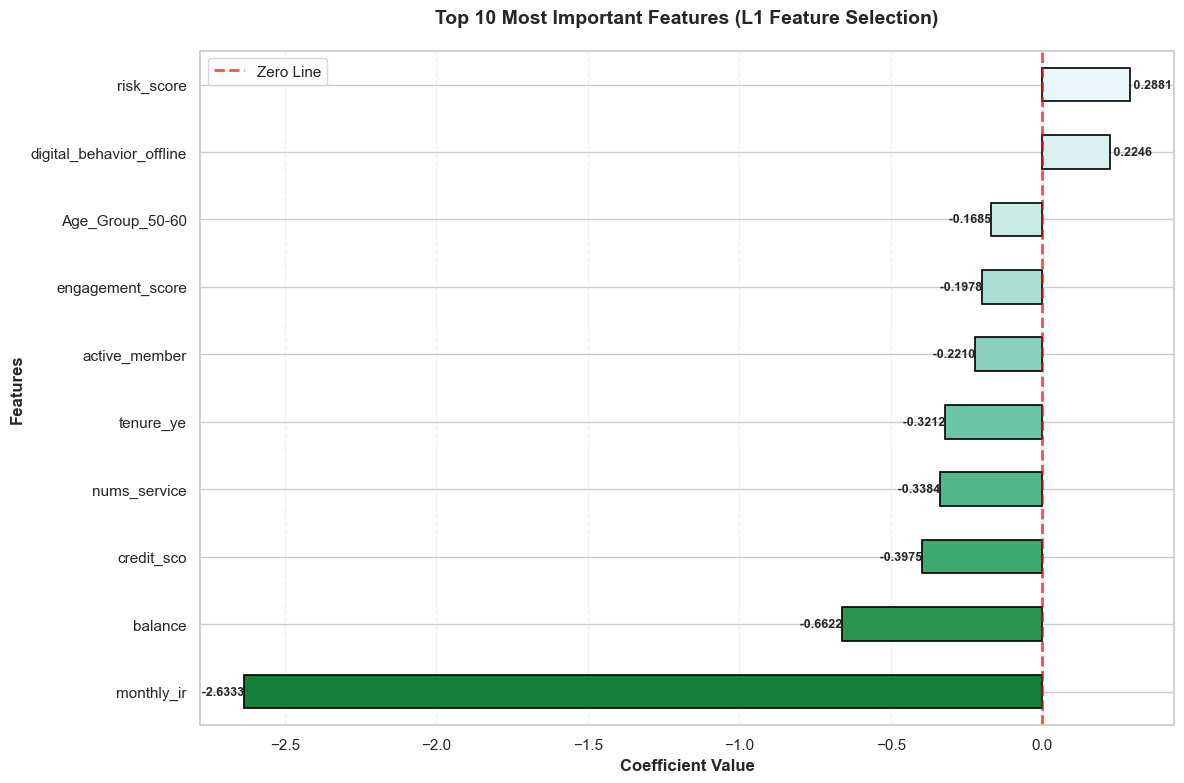


Selected features (1644): ['credit_sco', 'age', 'balance', 'monthly_ir', 'tenure_ye', 'nums_card', 'nums_service', 'active_member', 'last_transaction_month', 'engagement_score']...


In [ ]:
# Feature selection using SelectFromModel
# Dùng LogisticRegression với L1 penalty và C cố định
lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',  
    C=0.1,  # Regularization strength (lower = more regularization)
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    tol=1e-3
)

print("Training L1 model for feature selection...")
lasso.fit(X_train_scaled, y_train)

# Sử dụng SelectFromModel để chọn features
selector = SelectFromModel(lasso, prefit=True, threshold='median')
X_train_selected = selector.transform(X_train_scaled)

# Lấy tên của selected features
selected_mask = selector.get_support()
selected_features = X_train_scaled.columns[selected_mask].tolist()

# Feature importance
coef = pd.Series(lasso.coef_[0], index=X_train_scaled.columns)
print(f"\nTotal features: {len(coef)}")
print(f"Selected features (non-zero): {len(selected_features)}")
print(f"Removed features: {len(coef) - len(selected_features)}")

# Top features
print("\nTop 10 Most Important Features:")
top_10_features = coef.abs().sort_values(ascending=False).head(10)
print(top_10_features)

# Visualize top 10 features
plt.figure(figsize=(12, 8))
top_10_coef = coef[top_10_features.index].sort_values()
colors = plt.cm.BuGn_r(np.linspace(0.2, 0.9, len(top_10_coef)))
ax = top_10_coef.plot(kind='barh', color=colors, edgecolor='black', linewidth=1.2)
plt.title("Top 10 Most Important Features (L1 Feature Selection)", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Coefficient Value", fontsize=12, fontweight='bold')
plt.ylabel("Features", fontsize=12, fontweight='bold')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Zero Line')
# Add value labels
for i, (idx, value) in enumerate(top_10_coef.items()):
    ax.text(value, i, f' {value:.4f}', 
            va='center', ha='left' if value > 0 else 'right',
            fontsize=9, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

print(f"\nSelected features ({len(selected_features)}): {selected_features[:10]}..." if len(selected_features) > 10 else f"\nSelected features ({len(selected_features)}): {selected_features}")

# Prepare data với selected features
X_train_fs = X_train_scaled[selected_features]
X_test_fs = X_test_scaled[selected_features]

FINAL MODEL (With Feature Selection)

TRAIN SET PERFORMANCE:
ROC-AUC: 0.8825
              precision    recall  f1-score   support

           0       0.96      0.76      0.85     49200
           1       0.44      0.86      0.58     10800

    accuracy                           0.77     60000
   macro avg       0.70      0.81      0.71     60000
weighted avg       0.87      0.77      0.80     60000


TEST SET PERFORMANCE:
ROC-AUC: 0.8213
              precision    recall  f1-score   support

           0       0.93      0.73      0.82     16400
           1       0.39      0.77      0.51      3600

    accuracy                           0.74     20000
   macro avg       0.66      0.75      0.67     20000
weighted avg       0.84      0.74      0.77     20000



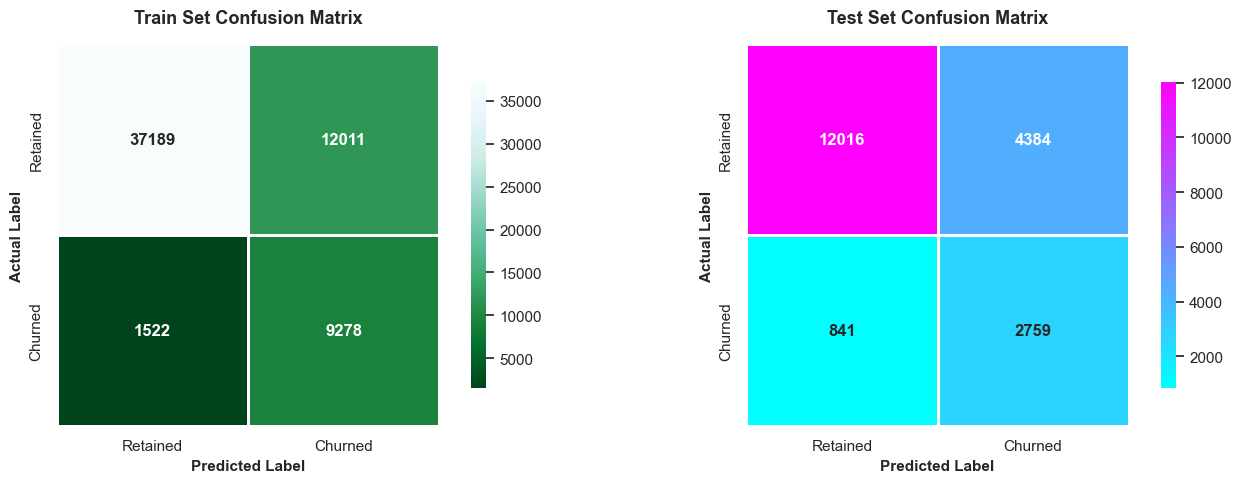

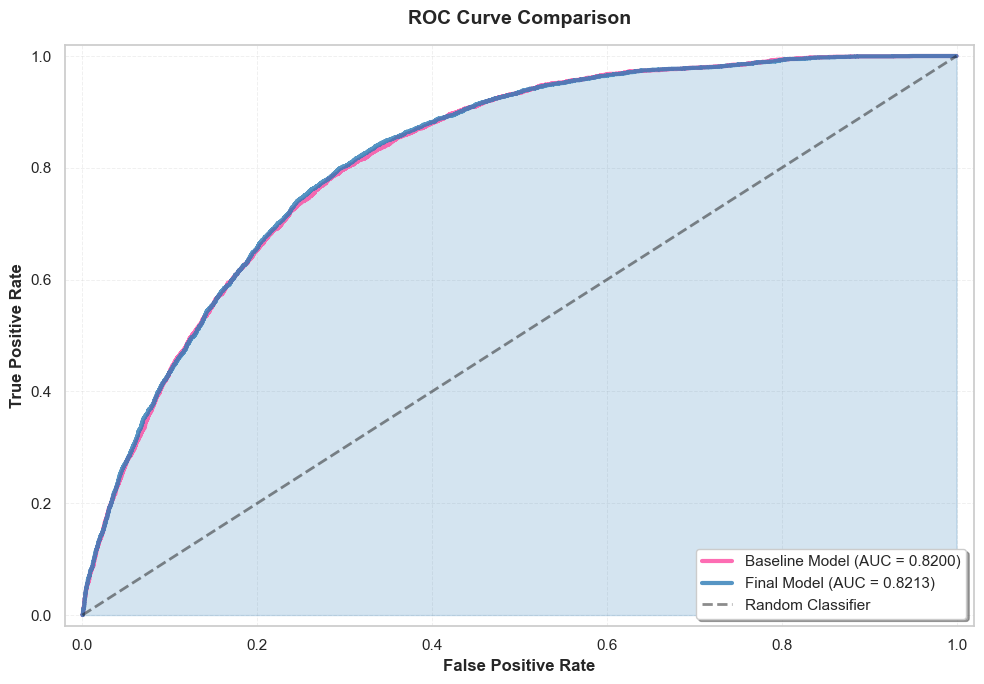


All Model Coefficients (sorted by importance):
monthly_ir                     1.573797
risk_score                     1.033463
balance                        0.740626
customer_segment_Priority      0.591617
tenure_ye                      0.284874
                                 ...   
last_active_date_09/01/2023    0.007308
created_date_17/12/2021        0.007198
created_date_12/08/2021        0.007013
created_date_02/09/2021        0.006338
nums_card                      0.000200
Length: 1644, dtype: float64

Model Coefficients (with sign):
risk_score                     1.033463
Income_Balance_Ratio           0.103440
digital_behavior_offline       0.066236
last_active_date_03/06/2021    0.045505
created_date_05/06/2025        0.044105
                                 ...   
occupation_Quản lý/Lãnh đạo   -0.274494
tenure_ye                     -0.284874
customer_segment_Priority     -0.591617
balance                       -0.740626
monthly_ir                    -1.573797
Length: 16

In [ ]:
print("FINAL MODEL (With Feature Selection)")
final_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    tol=1e-3  # Tăng tolerance để converge nhanh hơn
)
final_model.fit(X_train_fs, y_train)

# Predictions
y_train_pred = final_model.predict(X_train_fs)
y_train_prob = final_model.predict_proba(X_train_fs)[:,1]
y_test_pred = final_model.predict(X_test_fs)
y_test_prob = final_model.predict_proba(X_test_fs)[:,1]

# Performance Metrics
print("\nTRAIN SET PERFORMANCE:")
print(f"ROC-AUC: {roc_auc_score(y_train, y_train_prob):.4f}")
print(classification_report(y_train, y_train_pred))

print("\nTEST SET PERFORMANCE:")
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_prob):.4f}")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='BuGn_r', ax=axes[0],
            linewidths=2, linecolor='white', square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_xlabel("Predicted Label", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Actual Label", fontsize=11, fontweight='bold')
axes[0].set_title("Train Set Confusion Matrix", fontsize=13, fontweight='bold', pad=15)
axes[0].set_xticklabels(['Retained', 'Churned'])
axes[0].set_yticklabels(['Retained', 'Churned'])

cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='cool', ax=axes[1],
            linewidths=2, linecolor='white', square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_xlabel("Predicted Label", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Actual Label", fontsize=11, fontweight='bold')
axes[1].set_title("Test Set Confusion Matrix", fontsize=13, fontweight='bold', pad=15)
axes[1].set_xticklabels(['Retained', 'Churned'])
axes[1].set_yticklabels(['Retained', 'Churned'])

plt.tight_layout()
plt.show()

# ROC Curves Comparison
plt.figure(figsize=(10, 7))

# Baseline
fpr_base, tpr_base, _ = roc_curve(y_test, y_test_prob_baseline)
auc_base = roc_auc_score(y_test, y_test_prob_baseline)
plt.plot(fpr_base, tpr_base, label=f"Baseline Model (AUC = {auc_base:.4f})", 
         linewidth=3, color='#FD49A0', alpha=0.8)  # plasma color

# Final model
fpr_final, tpr_final, _ = roc_curve(y_test, y_test_prob)
auc_final = roc_auc_score(y_test, y_test_prob)
plt.plot(fpr_final, tpr_final, label=f"Final Model (AUC = {auc_final:.4f})", 
         linewidth=3, color='#2C7BB6', alpha=0.8)  # cool color

plt.plot([0,1], [0,1], 'k--', label='Random Classifier', linewidth=2, alpha=0.5)
plt.fill_between(fpr_final, tpr_final, alpha=0.2, color='#2C7BB6')
plt.xlabel("False Positive Rate", fontsize=12, fontweight='bold')
plt.ylabel("True Positive Rate", fontsize=12, fontweight='bold')
plt.title("ROC Curve Comparison", fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
plt.grid(alpha=0.3, linestyle='--', linewidth=0.7)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()

# Feature Importance (Final Model)
coef_final = pd.Series(
    final_model.coef_[0],
    index=selected_features
).sort_values()

print("\nAll Model Coefficients (sorted by importance):")
print(coef_final.abs().sort_values(ascending=False))
print("\nModel Coefficients (with sign):")
print(coef_final.sort_values(ascending=False))

In [ ]:
print("SUMMARY")
print(f"Original features: {X_train_encoded.shape[1]}")
print(f"Selected features: {len(selected_features)}")
print(f"\nBaseline Test ROC-AUC: {roc_auc_score(y_test, y_test_prob_baseline):.4f}")
print(f"Final Model Test ROC-AUC: {roc_auc_score(y_test, y_test_prob):.4f}")
print(f"Improvement: {(roc_auc_score(y_test, y_test_prob) - roc_auc_score(y_test, y_test_prob_baseline)):.4f}")

SUMMARY
Original features: 3287
Selected features: 1644

Baseline Test ROC-AUC: 0.8200
Final Model Test ROC-AUC: 0.8213
Improvement: 0.0013
